In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

<h1>CUP - SVM</h1>
<p>Exploring the cup dataset with SVM Classifier.</p>
<hr/>

In [2]:
import importlib

import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, \
    r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict, KFold
import cup_common as cc
import svm_common as sc
import cross_common as cr
from cross_common import MEE,MSE,RMSE,MAE,R2


In [3]:
importlib.reload(sc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [4]:
gamma_values = np.logspace(1, 1.8, 6)

# Note: The regularization parameter C is explored on a logarithmic scale over four orders of magnitude,
# from strong (0.1) to weak regularization (100), following standard practice for SVM hyperparameter tuning.
param_grid_coarse = [
    {  # custom
        "model__estimator__kernel": [cr.CustomRBFKernel(g) for g in gamma_values],
        "model__estimator__C": [1e-2, 1e0, 1e2, 1e4],
        "model__estimator__gamma": [1e-4, 1e-2, 1e0],
        "model__estimator__epsilon": [0.01, 0.1, 0.5],
    },
    # {  # linear
    #     "model__estimator__kernel": ["linear"],
    #     "model__estimator__C": [0.1, 1, 10, 100],
    #     "model__estimator__epsilon": [0.01, 0.05, 0.1, 0.2],
    # },
    # {  # rbf
    #     "model__estimator__kernel": ["rbf"],
    #     "model__estimator__C": [1e-2, 1e0, 1e2, 1e4],
    #     "model__estimator__gamma": [1e-4, 1e-2, 1e0],
    #     "model__estimator__epsilon": [0.01, 0.1, 0.5],
    # },
    # {  # poly
    #     "model__estimator__kernel": ["poly"],
    #     "model__estimator__C": [1e-2, 1e0, 1e2, 1e4],
    #     "model__estimator__gamma": [1e-4, 1e-3, 1e-2, 1e-1],
    #     "model__estimator__epsilon": [0.01, 0.1, 0.5],
    #     "model__estimator__degree": [2, 3],
    #     "model__estimator__coef0": [0, 1],
    # }
]

# We only test SVR
pipe_default = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(SVR()))
])

# --- The metrics to compute in training ---
metrics_dict = {
    MEE: (cr.mee, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    R2: (cr.r2,max),
}
the_metrics = metrics_dict.keys()
# ------------------------------------------

# Common scoring
default_metric = MEE
scoring = cr.common_scoring(default_metric)

# Common CV fold strategy
outer_cv = cr.common_fold_strategy()


In [5]:
def refine_log(center, factors=(0.3, 1, 3)):
    """
    Generate a refined log-scale grid around center.
    Example: center=100 → [30, 100, 300]
    """
    return sorted([center * f for f in factors])


def refine_linear(center, step=0.1, n=3, min_val=1e-4):
    """
    Generate a linear grid around center.
    Example: center=0.2 → [0.1, 0.2, 0.3]
    """
    half = n // 2
    values = [center + (i - half) * step for i in range(n)]
    return sorted([max(v, min_val) for v in values])


def build_grid_params(grid_params: dict):
    param_grid = {"model__estimator__kernel": [grid_params["kernel"]]}
    for param in grid_params:
        if param == 'kernel': continue
        if param == 'epsilon':
            param_grid["model__estimator__epsilon"]=refine_linear(grid_params["epsilon"], step=0.05)
        else:
            refined = refine_log(grid_params[param])
            print(f"{param} - former: {grid_params[param]} refined: {refined}")
            param_grid[f"model__estimator__{param}"]=refined

    return param_grid

<h3>Data Loading</h3>

In [6]:
df_train, df_test = cc.load_set()
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)
features_names = X_tr.columns
cr.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,15,11
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [7]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h3>Best Model</h3>

<h4>Coarse Grid</h4>

In [8]:
# Perform a grid search
gs_coarse = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_coarse,
    cv = outer_cv,
    scoring = scoring,
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
gs_coarse.fit(X_tr, y_tr)
best_coarse_estimator = gs_coarse.best_estimator_
best_coarse_grid_model, best_coarse_grid_params = cr.extract_best_pipeline_metrics_from_grid(gs_coarse)
cr.grid_introspection(gs_coarse)

Grid summary
----------------------------------------
Total model explored: 216  splits: 5
Best params: {'model__estimator__C': 100.0, 'model__estimator__epsilon': 0.01, 'model__estimator__gamma': 0.0001, 'model__estimator__kernel': <cross_common.CustomRBFKernel object at 0x121bcd7f0>}
Best score: -20.983676670512985
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=SVR(C=100.0, epsilon=0.01,
                                                    gamma=0.0001,
                                                    kernel=<cross_common.CustomRBFKernel object at 0x121b85260>)))])


<h4>Medium Grid</h4>

In [9]:
param_grid_medium = build_grid_params(best_coarse_grid_params)
gs_medium = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_medium,
    cv = outer_cv,
    scoring = scoring,
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
gs_medium.fit(X_tr, y_tr)
best_medium_estimator = gs_medium.best_estimator_
best_medium_grid_model, best_medium_grid_params = cr.extract_best_pipeline_metrics_from_grid(gs_medium)
cr.grid_introspection(gs_medium)

C - former: 100.0 refined: [30.0, 100.0, 300.0]
gamma - former: 0.0001 refined: [3e-05, 0.0001, 0.00030000000000000003]
Grid summary
----------------------------------------
Total model explored: 27  splits: 5
Best params: {'model__estimator__C': 100.0, 'model__estimator__epsilon': 0.0001, 'model__estimator__gamma': 3e-05, 'model__estimator__kernel': <cross_common.CustomRBFKernel object at 0x121bcd7f0>}
Best score: -20.98144348407909
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=SVR(C=100.0, epsilon=0.0001,
                                                    gamma=3e-05,
                                                    kernel=<cross_common.CustomRBFKernel object at 0x121ca2f30>)))])


<h4>Fine Grid</h4>

In [10]:
param_grid_fine = build_grid_params(best_medium_grid_params)
gs_fine = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_fine,
    cv = outer_cv,
    scoring = scoring,
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
gs_fine.fit(X_tr, y_tr)
best_fine_estimator = gs_fine.best_estimator_
best_fine_grid_model, best_fine_grid_params = cr.extract_best_pipeline_metrics_from_grid(gs_fine)
cr.grid_introspection(gs_fine)

C - former: 100.0 refined: [30.0, 100.0, 300.0]
gamma - former: 3e-05 refined: [9e-06, 3e-05, 9e-05]
Grid summary
----------------------------------------
Total model explored: 27  splits: 5
Best params: {'model__estimator__C': 100.0, 'model__estimator__epsilon': 0.0001, 'model__estimator__gamma': 9e-06, 'model__estimator__kernel': <cross_common.CustomRBFKernel object at 0x121bcd7f0>}
Best score: -20.98144348407909
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=SVR(C=100.0, epsilon=0.0001,
                                                    gamma=9e-06,
                                                    kernel=<cross_common.CustomRBFKernel object at 0x11cafc710>)))])


<h3>Learning Curve</h3>
<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>

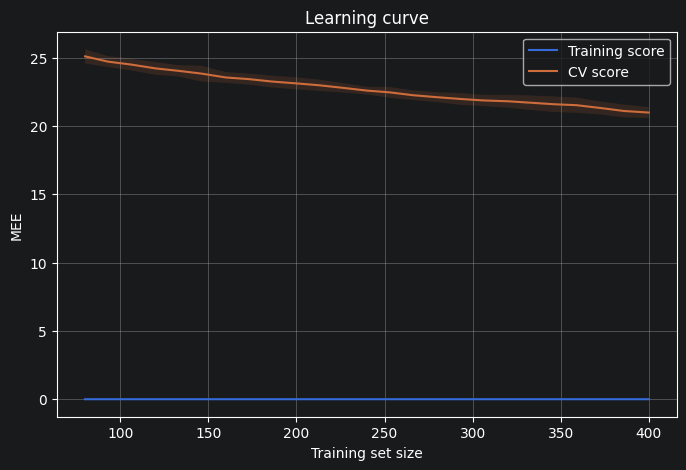

In [11]:
from sklearn.base import clone

clean_pipeline = clone(pipe_default).set_params(**gs_fine.best_params_)
cr.plot_learning_curve(clean_pipeline, X_tr, y_tr, outer_cv, scoring=scoring)

<h2>Model estimation</h2>
<p>The model is estimated trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [12]:
non_nested_runner = cr.SklearnRegressorRunner(gs_fine)
non_nested_result = cr.kfold(non_nested_runner, X_tr, y_tr, outer_cv,metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 20.8293
Validation MSE       | 135.4854
Validation MAE       | 9.4905
Validation RMSE      | 11.6398
Validation R2        | 0.5548
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 20.5651
Validation MSE       | 134.2261
Validation MAE       | 9.3837
Validation RMSE      | 11.5856
Validation R2        | 0.5215
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 20.6897
Validation MSE       | 128.7737
Validation MAE       | 9.4520
Validation RMS

In [13]:
best_idx = gs_fine.best_index_
mean_score = gs_fine.cv_results_["mean_test_score"][best_idx]
std_score  = gs_fine.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(non_nested_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -20.9814 ± 0.3950
Best CV func score: 20.9814 ± 0.3950


<h3>Nested Cross Validation</h3>

In [14]:
importlib.reload(cr)

inner_cv = cr.common_fold_strategy(n_split=3)

gs_inner = GridSearchCV(
    pipe_default,
    param_grid=param_grid_fine,
    scoring=scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv, metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 27  splits: 3
Best params: {'model__estimator__C': 100.0, 'model__estimator__epsilon': 0.0001, 'model__estimator__gamma': 9e-06, 'model__estimator__kernel': <cross_common.CustomRBFKernel object at 0x121f28780>}
Best score: -21.94667812706466
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=SVR(C=100.0, epsilon=0.0001,
                                                    gamma=9e-06,
                                                    kernel=<cross_common.CustomRBFKernel object at 0x121dbc6e0>)))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 20.8293
Validation MSE       | 135.4854
Validation MAE       | 9.4905
Validation RMSE      | 11.6398
Validation R2        | 0.5548
Train                | samples: 400
Va

<h3>Results</h3>
<hr/>

<p>We expect that non nested KFold result has more optimistic metrics in respect to nested KFold.</p>

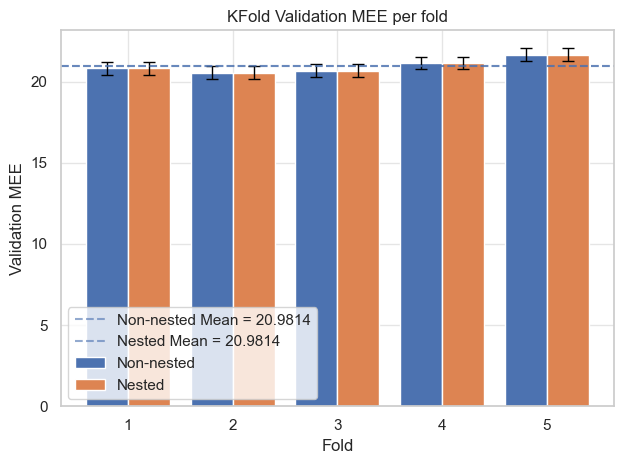

mee TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.000517,20.829286,20.828769
2,0.000546,20.565136,20.564590
3,0.000519,20.689662,20.689143
4,0.000544,21.158168,21.157624
5,0.000537,21.664964,21.664427
MEAN,0.000533,20.981443,20.980911
STD,0.000012,0.394976,0.394973


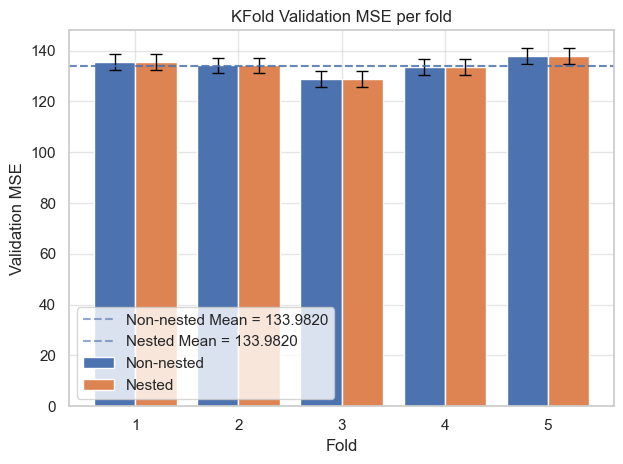

mse TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,8.108144e-08,135.485442,135.485442
2,8.557099e-08,134.226075,134.226075
3,8.019401e-08,128.773690,128.773690
4,8.311905e-08,133.527160,133.527160
5,9.026270e-08,137.897712,137.897712
MEAN,8.404564e-08,133.982016,133.982016
STD,3.618249e-09,2.999536,2.999536


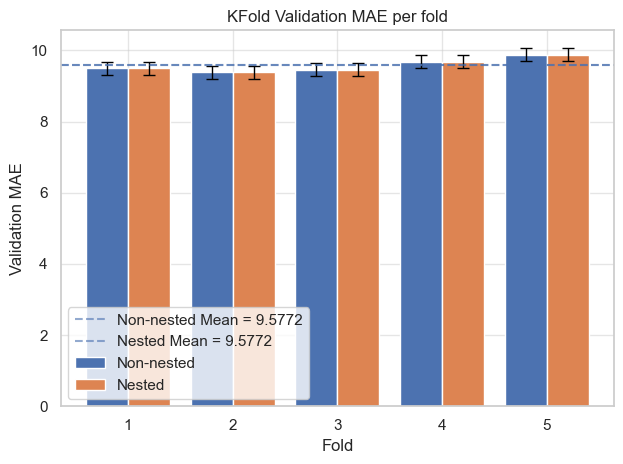

mae TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.000240,9.490496,9.490256
2,0.000249,9.383673,9.383424
3,0.000241,9.452037,9.451796
4,0.000243,9.682145,9.681902
5,0.000251,9.877723,9.877472
MEAN,0.000245,9.577215,9.576970
STD,0.000004,0.179980,0.179978


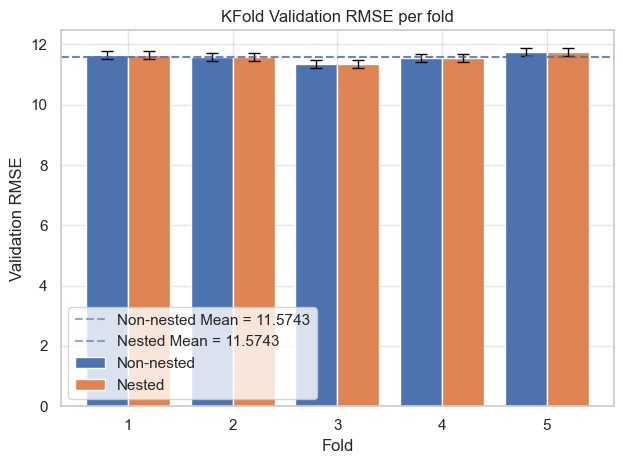

rmse TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.000285,11.639821,11.639537
2,0.000293,11.585598,11.585305
3,0.000283,11.347850,11.347566
4,0.000288,11.555395,11.555107
5,0.000300,11.742986,11.742685
MEAN,0.000290,11.574330,11.574040
STD,0.000006,0.130010,0.130005


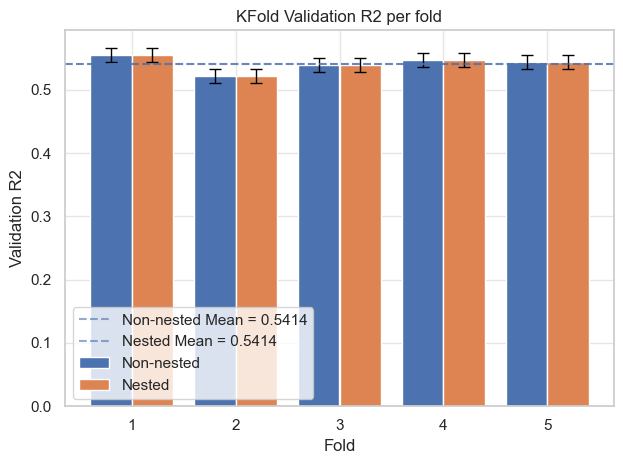

r2 TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,1.000000e+00,0.554755,-0.445245
2,1.000000e+00,0.521509,-0.478491
3,1.000000e+00,0.539152,-0.460848
4,1.000000e+00,0.547189,-0.452811
5,1.000000e+00,0.544322,-0.455678
MEAN,1.000000e+00,0.541386,-0.458614
STD,1.172517e-11,0.011146,0.011146


In [15]:
for metric in the_metrics:
    cr.plot_kfold_metric([(non_nested_result,"Non-nested"), (nested_result, "Nested")], metric)
    print(f"{metric} TR vs VL from KFold Nested results")
    display(cr.kfold_summary(nested_result, use=metric))

<h3>Bootstrap Variance</h3>
<p>Bootstrap is applied to approximate the sampling distribution of the estimator when only a finite dataset is available. By generating multiple resampled datasets, we can estimate variance, assess model stability, and better understand generalization behavior.</p>

In [16]:
importlib.reload(cr)
bootstrap_samples = 100
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
bootstrap_params = {"silence_output": True}
# due to little discrepancy from nested and non nested runner in SVM, we use nested_runner as it is faster
# furthermore we are not in model selection phase
bootstrap_scores = cr.bootstrap_out_of_bag_scores(non_nested_runner, X_tr, y_tr, samples, metrics_dict, bootstrap_params=bootstrap_params)
cr.aggregate_scores(bootstrap_scores)

,Metric,Mean,Std,%
0,MSE,143.85,9.56,6.65
1,R2,0.51,0.02,3.35
2,MAE,9.93,0.36,3.66
3,RMSE,11.99,0.40,3.33
4,MEE,21.76,0.74,3.42


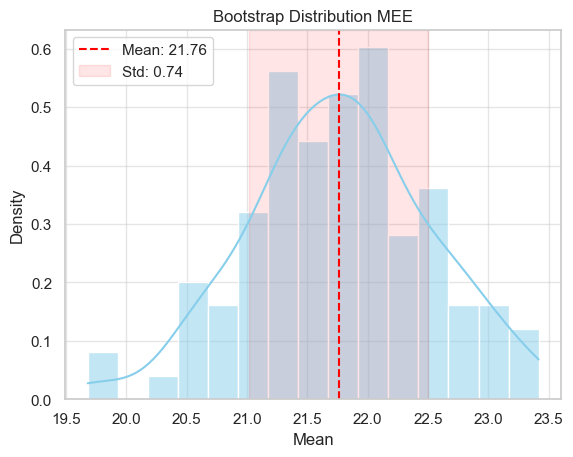

In [17]:
cr.plot_bootstrap_distribution([metric[MEE] for metric in bootstrap_scores], title=f"Bootstrap Distribution {default_metric.upper()}")

<h2>Test predictions</h2>
<hr/>

In [18]:
fitted_model = non_nested_runner.fitted_model(X_tr, y_tr)
y_pred = non_nested_runner.predict(fitted_model, X_ts)

In [19]:
print(y_pred)

[[ -0.93436451   0.04989542   5.50064485  -7.82127408]
 [-12.24049404 -13.12724713 -40.912097    13.48441398]
 [ -0.1093041   -0.2651369   -4.80776361   8.01336784]
 ...
 [ -1.25592942   6.51557846  15.40385491 -13.0791508 ]
 [  2.31745155  10.53693332 -27.65494562  18.30510172]
 [  2.2441365   -0.72944315   3.6816657   -8.12151447]]


<hr/>